# Encoder–Decoder Architectures and Attention

This notebook includes:
1. Conceptual explanation of the **encoder–decoder architecture**
2. Figures showing how information flows through the model
3. Discussion of how **CNNs, RNNs, and LSTMs** can be used as encoders/decoders
4. A worked **sequence-to-sequence** example with PyTorch
5. Assignment prompts for **image captioning** and **question answering**
6. A section on **attention**, including code that **learns attention parameters**

---

## Learning goals
By the end of this notebook, you should be able to:
- Explain what an encoder and a decoder do
- Distinguish between fixed-context seq2seq and attention-based seq2seq
- Identify when CNNs, RNNs, and LSTMs are good encoder/decoder choices
- Train a simple attention-based model in PyTorch
- Design encoder–decoder systems for image captioning and question answering

## Why encoder–decoder models?
Many machine learning problems can be framed as:

**Input structure → compressed representation → output structure**

Examples:
- Sentence in French → sentence in English
- Image → caption
- Passage + question → answer
- Speech signal → text

The **encoder** reads the input and converts it into hidden representations.
The **decoder** uses those representations to generate the output.

A useful way to think about it:
- The encoder answers: **"What is in the input?"**
- The decoder answers: **"What should I generate next?"**

In [3]:
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, ArrowStyle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Figure 1: Basic encoder–decoder idea
The classic seq2seq model converts an input sequence into a context representation, then unfolds an output sequence.

In the earliest encoder–decoder models, the entire input was often compressed into a **single context vector**.  
That works for short sequences, but becomes difficult for longer inputs.

## What can play the role of encoder or decoder?

### 1. RNN / GRU / LSTM as an encoder
These are common when the input is a sequence:
- machine translation
- speech
- time series
- text classification

The encoder reads tokens one-by-one and updates its hidden state.

### 2. RNN / GRU / LSTM as a decoder
These are common when the output is sequential:
- translation
- caption generation
- dialog generation
- structured text output

The decoder predicts one token at a time.

### 3. CNN as an encoder
CNNs are natural for **images**, because they extract spatial features.
Examples:
- image captioning: image → caption
- visual question answering: image + question → answer
- OCR or scene text recognition pipelines

A CNN can also encode sequences using **1D convolutions**.

### 4. CNN as a decoder
CNN decoders appear when the output has spatial structure:
- segmentation masks
- image reconstruction
- image generation
- super-resolution

Examples often use **transpose convolutions** or upsampling blocks.

### 5. Hybrid models
Many real systems are hybrid:
- **CNN encoder + LSTM decoder** for image captioning
- **RNN encoder + RNN decoder** for translation
- **CNN encoder + Transformer decoder**
- **Transformer encoder + Transformer decoder**

## A small but important limitation of the original seq2seq model
In the earliest encoder–decoder approach, the encoder often produced one final hidden state that acted as a single summary vector.

This creates a **bottleneck**:
- short sequences may work fine
- long sequences become harder
- the decoder may lose access to detailed earlier information

That limitation is one main reason **attention** became so important.

# Part A — A simple seq2seq dataset example

To keep the notebook classroom-friendly and easy to run, we use a **toy sequence transduction dataset**.

### Task
Convert an input sequence of digits written as words into the reversed sequence.

Example:
- input: `"one two three"`
- output: `"three two one"`

This is useful because:
- it is a real sequence-to-sequence problem
- output length can vary
- the decoder must depend on the encoded input
- we can compare non-attention and attention ideas clearly

In [4]:
digit_words = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]

def make_example(min_len=3, max_len=7):
    L = random.randint(min_len, max_len)
    seq = [random.choice(digit_words) for _ in range(L)]
    src = seq
    tgt = list(reversed(seq))
    return src, tgt

pairs = [make_example() for _ in range(2000)]
pairs[:5]

[(['two', 'six', 'zero', 'one', 'eight'],
  ['eight', 'one', 'zero', 'six', 'two']),
 (['five', 'nine', 'zero'], ['zero', 'nine', 'five']),
 (['three', 'zero', 'one', 'six', 'six', 'one', 'three'],
  ['three', 'one', 'six', 'six', 'one', 'zero', 'three']),
 (['eight', 'six', 'zero'], ['zero', 'six', 'eight']),
 (['one', 'three', 'nine', 'zero', 'nine', 'nine', 'six'],
  ['six', 'nine', 'nine', 'zero', 'nine', 'three', 'one'])]

In [5]:
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]
vocab = SPECIALS + digit_words
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

PAD_IDX = stoi["<pad>"]
SOS_IDX = stoi["<sos>"]
EOS_IDX = stoi["<eos>"]
UNK_IDX = stoi["<unk>"]

def encode_tokens(tokens):
    return [stoi.get(tok, UNK_IDX) for tok in tokens]

def decode_indices(indices):
    tokens = []
    for idx in indices:
        tok = itos[int(idx)]
        if tok == "<eos>":
            break
        if tok not in ("<sos>", "<pad>"):
            tokens.append(tok)
    return tokens

class ToySeq2SeqDataset(Dataset):
    def __init__(self, pairs):
        self.data = []
        for src, tgt in pairs:
            src_ids = encode_tokens(src) + [EOS_IDX]
            tgt_ids = [SOS_IDX] + encode_tokens(tgt) + [EOS_IDX]
            self.data.append((src_ids, tgt_ids))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def collate_batch(batch):
    srcs, tgts = zip(*batch)
    max_src = max(len(x) for x in srcs)
    max_tgt = max(len(x) for x in tgts)

    src_tensor = torch.full((len(batch), max_src), PAD_IDX, dtype=torch.long)
    tgt_tensor = torch.full((len(batch), max_tgt), PAD_IDX, dtype=torch.long)

    for i, (src, tgt) in enumerate(zip(srcs, tgts)):
        src_tensor[i, :len(src)] = torch.tensor(src)
        tgt_tensor[i, :len(tgt)] = torch.tensor(tgt)

    return src_tensor, tgt_tensor

random.shuffle(pairs)
train_pairs = pairs[:1600]
val_pairs = pairs[1600:]

train_ds = ToySeq2SeqDataset(train_pairs)
val_ds = ToySeq2SeqDataset(val_pairs)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_batch)

len(train_ds), len(val_ds), len(vocab)

(1600, 400, 14)

## Baseline: LSTM encoder + LSTM decoder
This is the classic encoder–decoder setup:
- the **encoder LSTM** reads the input sequence
- the **decoder LSTM** generates the output sequence one step at a time
- the decoder is initialized using the encoder's final state

Below we implement a compact version.

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(emb)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tokens, hidden, cell):
        # input_tokens: [B]
        emb = self.embedding(input_tokens).unsqueeze(1)   # [B,1,E]
        out, (hidden, cell) = self.lstm(emb, (hidden, cell))
        logits = self.fc_out(out.squeeze(1))
        return logits, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = len(vocab)
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)

        _, hidden, cell = self.encoder(src)
        input_tokens = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            logits, hidden, cell = self.decoder(input_tokens, hidden, cell)
            outputs[:, t] = logits
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_tokens = tgt[:, t] if teacher_force else top1

        return outputs

encoder = Encoder(len(vocab)).to(device)
decoder = Decoder(len(vocab)).to(device)
baseline_model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(baseline_model.parameters(), lr=0.003)

print(sum(p.numel() for p in baseline_model.parameters()))

202254


In [7]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.6)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        output = model(src, tgt, teacher_forcing_ratio=0.0)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

baseline_history = {"train": [], "val": []}
for epoch in range(1, 9):
    tr = train_epoch(baseline_model, train_loader, optimizer, criterion)
    va = evaluate_epoch(baseline_model, val_loader, criterion)
    baseline_history["train"].append(tr)
    baseline_history["val"].append(va)
    print(f"Epoch {epoch:02d} | train loss={tr:.4f} | val loss={va:.4f}")

Epoch 01 | train loss=2.0724 | val loss=1.5872
Epoch 02 | train loss=1.3451 | val loss=1.3294
Epoch 03 | train loss=1.0231 | val loss=1.1161
Epoch 04 | train loss=0.8759 | val loss=0.9262
Epoch 05 | train loss=0.6300 | val loss=0.7071
Epoch 06 | train loss=0.4888 | val loss=0.5748
Epoch 07 | train loss=0.3317 | val loss=0.4134
Epoch 08 | train loss=0.2333 | val loss=0.3326


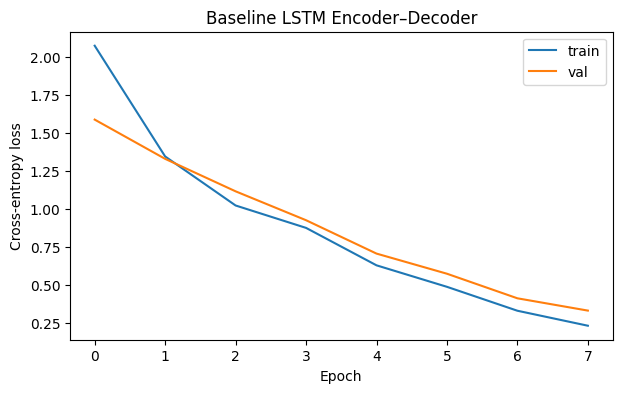

In [8]:
plt.figure(figsize=(7,4))
plt.plot(baseline_history["train"], label="train")
plt.plot(baseline_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Baseline LSTM Encoder–Decoder")
plt.legend()
plt.show()

In [9]:
@torch.no_grad()
def greedy_decode_baseline(model, src_tokens, max_len=15):
    model.eval()
    src = torch.tensor([encode_tokens(src_tokens) + [EOS_IDX]], dtype=torch.long, device=device)
    _, hidden, cell = model.encoder(src)

    input_tok = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
    generated = []
    for _ in range(max_len):
        logits, hidden, cell = model.decoder(input_tok, hidden, cell)
        next_tok = logits.argmax(1)
        idx = int(next_tok.item())
        if idx == EOS_IDX:
            break
        generated.append(idx)
        input_tok = next_tok
    return decode_indices(generated)

examples = [
    ["one", "two", "three"],
    ["seven", "zero", "four", "two"],
    ["nine", "nine", "one", "three", "zero"],
]

for ex in examples:
    pred = greedy_decode_baseline(baseline_model, ex)
    print("input :", ex)
    print("pred  :", pred)
    print("truth :", list(reversed(ex)))
    print("-" * 50)

input : ['one', 'two', 'three']
pred  : ['three', 'two', 'one', 'two', 'four']
truth : ['three', 'two', 'one']
--------------------------------------------------
input : ['seven', 'zero', 'four', 'two']
pred  : ['two', 'four', 'zero', 'seven', 'zero']
truth : ['two', 'four', 'zero', 'seven']
--------------------------------------------------
input : ['nine', 'nine', 'one', 'three', 'zero']
pred  : ['zero', 'three', 'one', 'nine', 'nine', 'nine']
truth : ['zero', 'three', 'one', 'nine', 'nine']
--------------------------------------------------


## Interpreting the baseline
The baseline learns the task because the input and output are strongly related.
However, for longer or more complex tasks, relying on a **single final encoder state** becomes limiting.

That leads us to **attention**.

# Part B — Attention mechanism

## Idea
Instead of forcing the decoder to rely on only one compressed context vector, let it look back at **all encoder hidden states**.

At decoder step \(t\):
1. compare current decoder state with encoder states
2. compute a score for each encoder position
3. normalize those scores into attention weights
4. build a weighted sum of encoder states
5. use that context to predict the next token

This makes the model more flexible, especially for longer inputs.

## Figure 3: Encoder–decoder with attention

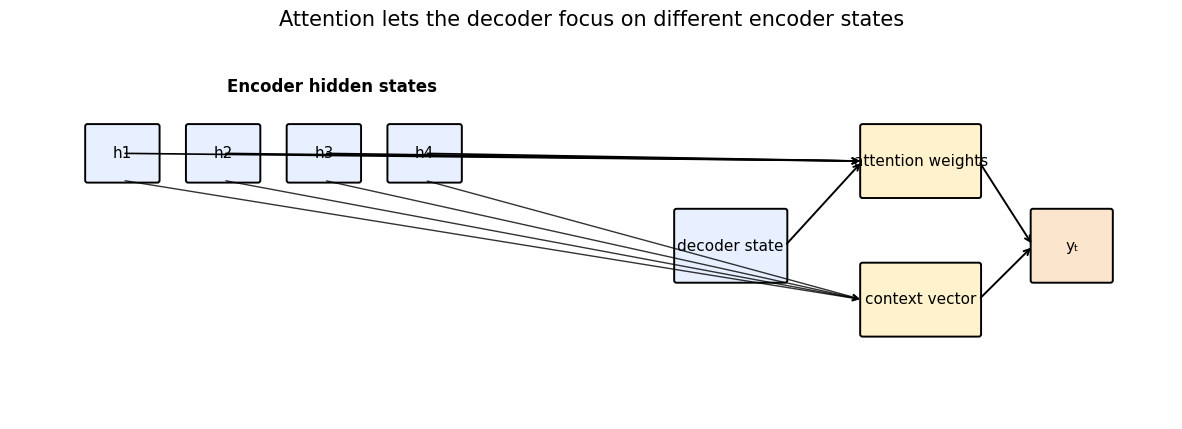

In [10]:
def draw_attention_figure():
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 5)
    ax.axis("off")

    def box(x, y, w, h, txt, fc="#f5f5f5"):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03",
                                    linewidth=1.4, facecolor=fc, edgecolor="black"))
        ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=11)

    enc_x = [1.0, 2.3, 3.6, 4.9]
    for i, x in enumerate(enc_x, 1):
        box(x, 3.1, 0.9, 0.7, f"h{i}", fc="#e8f0ff")

    box(8.6, 1.8, 1.4, 0.9, "decoder state", fc="#e8f0ff")
    box(11.0, 2.9, 1.5, 0.9, "attention weights", fc="#fff2cc")
    box(11.0, 1.1, 1.5, 0.9, "context vector", fc="#fff2cc")
    box(13.2, 1.8, 1.0, 0.9, "yₜ", fc="#fce5cd")

    for x in enc_x:
        ax.annotate("", xy=(11.0, 3.35), xytext=(x + 0.45, 3.45),
                    arrowprops=dict(arrowstyle="->", linewidth=1.2))
        ax.annotate("", xy=(11.0, 1.55), xytext=(x + 0.45, 3.1),
                    arrowprops=dict(arrowstyle="->", linewidth=1.0, alpha=0.8))

    ax.annotate("", xy=(11.0, 3.35), xytext=(10.0, 2.25), arrowprops=dict(arrowstyle="->", linewidth=1.4))
    ax.annotate("", xy=(13.2, 2.25), xytext=(12.5, 1.55), arrowprops=dict(arrowstyle="->", linewidth=1.4))
    ax.annotate("", xy=(13.2, 2.25), xytext=(12.5, 3.35), arrowprops=dict(arrowstyle="->", linewidth=1.4))

    ax.text(2.8, 4.25, "Encoder hidden states", fontsize=12, weight="bold")
    ax.set_title("Attention lets the decoder focus on different encoder states", fontsize=15)
    plt.show()

draw_attention_figure()

## 6. A Common Additive Attention Formulation

Additive attention (also known as **Bahdanau Attention**) allows the decoder to focus on different parts of the input sequence at each step of the output generation.

### 🔹 Step 1: The Alignment Score
For each encoder hidden state $h_i$ (where $i$ is the position in the input) and the current decoder hidden state $s_t$, we compute an energy score $e_{t,i}$. This score represents how well the input at position $i$ matches the current needs of the decoder at step $t$:

$$e_{t,i} = v^\top \tanh(W_h h_i + W_s s_t)$$

---

### 🔹 Step 2: The Attention Weights (Normalization)
We convert these raw scores into probabilities using a **Softmax** function. This ensures that all weights are between 0 and 1 and sum to 1:

$$\alpha_{t,i} = \text{softmax}(e_{t,i}) = \frac{\exp(e_{t,i})}{\sum_{j=1}^{T} \exp(e_{t,j})}$$

These $\alpha_{t,i}$ values tell the model which specific input words are most important for the current output word.

---

### 🔹 Step 3: The Context Vector
Finally, we compute the **context vector** $c_t$ as a weighted sum of the encoder hidden states. This vector acts as a "summary" of the input, filtered by the attention weights:

$$c_t = \sum_{i=1}^{T} \alpha_{t,i} h_i$$



---

### 🔹 Key Learnable Parameters
The intelligence of this mechanism lies in three parameters that are learned via backpropagation:
* **$W_h$**: A weight matrix that transforms the encoder states.
* **$W_s$**: A weight matrix that transforms the decoder state.
* **$v$**: A weight vector that collapses the combined representation into a single scalar score.

> **Intuition:** The model learns to "ask" for specific information ($W_s s_t$) and the encoder learns to "provide" it in a compatible format ($W_h h_i$).

## Attention model implementation in PyTorch
Below, we replace the fixed single-vector bottleneck with a learned attention module.

In [11]:
class AdditiveAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W_h = nn.Linear(hid_dim, hid_dim, bias=False)
        self.W_s = nn.Linear(hid_dim, hid_dim, bias=False)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask=None):
        # decoder_hidden: [B, H]
        # encoder_outputs: [B, S, H]
        dec = decoder_hidden.unsqueeze(1).repeat(1, encoder_outputs.size(1), 1)
        energy = torch.tanh(self.W_h(encoder_outputs) + self.W_s(dec))
        scores = self.v(energy).squeeze(-1)  # [B, S]

        if src_mask is not None:
            scores = scores.masked_fill(~src_mask, -1e9)

        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B,H]
        return context, attn_weights

class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = AdditiveAttention(hid_dim)
        self.lstm = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim * 2, vocab_size)

    def forward(self, input_tokens, hidden, cell, encoder_outputs, src_mask=None):
        emb = self.embedding(input_tokens)                       # [B,E]
        dec_hidden = hidden[-1]                                 # [B,H]
        context, attn_weights = self.attention(dec_hidden, encoder_outputs, src_mask)
        lstm_input = torch.cat([emb, context], dim=1).unsqueeze(1)  # [B,1,E+H]
        out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        logits = self.fc_out(torch.cat([out.squeeze(1), context], dim=1))
        return logits, hidden, cell, attn_weights

class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def make_src_mask(self, src):
        return src != PAD_IDX

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = len(vocab)

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)
        attn_store = []

        encoder_outputs, hidden, cell = self.encoder(src)
        src_mask = self.make_src_mask(src)
        input_tokens = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, cell, attn_weights = self.decoder(
                input_tokens, hidden, cell, encoder_outputs, src_mask
            )
            outputs[:, t] = logits
            attn_store.append(attn_weights.detach().cpu())
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_tokens = tgt[:, t] if teacher_force else top1

        return outputs, attn_store

attn_encoder = Encoder(len(vocab)).to(device)
attn_decoder = AttnDecoder(len(vocab)).to(device)
attn_model = AttnSeq2Seq(attn_encoder, attn_decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
attn_optimizer = optim.Adam(attn_model.parameters(), lr=0.003)

In [12]:
def train_epoch_attn(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output, _ = model(src, tgt, teacher_forcing_ratio=0.6)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch_attn(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        output, _ = model(src, tgt, teacher_forcing_ratio=0.0)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

attn_history = {"train": [], "val": []}
for epoch in range(1, 9):
    tr = train_epoch_attn(attn_model, train_loader, attn_optimizer, criterion)
    va = evaluate_epoch_attn(attn_model, val_loader, criterion)
    attn_history["train"].append(tr)
    attn_history["val"].append(va)
    print(f"Epoch {epoch:02d} | train loss={tr:.4f} | val loss={va:.4f}")

Epoch 01 | train loss=1.8267 | val loss=1.2597
Epoch 02 | train loss=0.8073 | val loss=0.3103
Epoch 03 | train loss=0.1965 | val loss=0.0766
Epoch 04 | train loss=0.0509 | val loss=0.0308
Epoch 05 | train loss=0.0246 | val loss=0.0584
Epoch 06 | train loss=0.0318 | val loss=0.0541
Epoch 07 | train loss=0.0187 | val loss=0.0196
Epoch 08 | train loss=0.0254 | val loss=0.0455


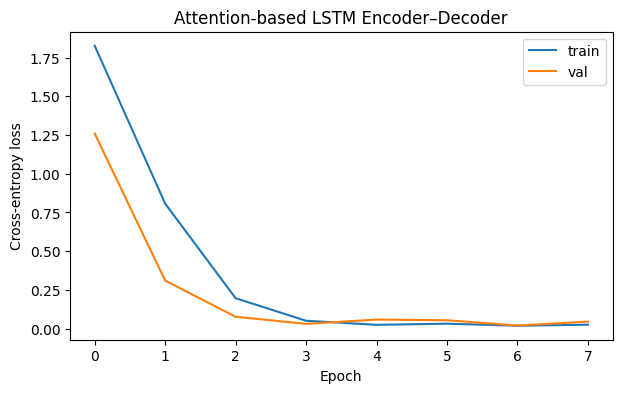

In [13]:
plt.figure(figsize=(7,4))
plt.plot(attn_history["train"], label="train")
plt.plot(attn_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Attention-based LSTM Encoder–Decoder")
plt.legend()
plt.show()

In [14]:
@torch.no_grad()
def greedy_decode_attn(model, src_tokens, max_len=15):
    model.eval()
    src_ids = encode_tokens(src_tokens) + [EOS_IDX]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.make_src_mask(src)

    input_tok = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
    generated = []
    all_attn = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(input_tok, hidden, cell, encoder_outputs, src_mask)
        next_tok = logits.argmax(1)
        idx = int(next_tok.item())
        all_attn.append(attn.squeeze(0).detach().cpu())
        if idx == EOS_IDX:
            break
        generated.append(idx)
        input_tok = next_tok
    return decode_indices(generated), torch.stack(all_attn)

for ex in examples:
    pred, attn = greedy_decode_attn(attn_model, ex)
    print("input :", ex)
    print("pred  :", pred)
    print("truth :", list(reversed(ex)))
    print("attention matrix shape:", tuple(attn.shape))
    print("-" * 50)

input : ['one', 'two', 'three']
pred  : ['three', 'three', 'three', 'two', 'one']
truth : ['three', 'two', 'one']
attention matrix shape: (6, 4)
--------------------------------------------------
input : ['seven', 'zero', 'four', 'two']
pred  : ['two', 'two', 'two', 'zero', 'seven']
truth : ['two', 'four', 'zero', 'seven']
attention matrix shape: (6, 5)
--------------------------------------------------
input : ['nine', 'nine', 'one', 'three', 'zero']
pred  : ['zero', 'zero', 'three', 'one', 'nine', 'nine']
truth : ['zero', 'three', 'one', 'nine', 'nine']
attention matrix shape: (7, 6)
--------------------------------------------------


## Visualizing learned attention weights
The following heatmap shows which input positions the decoder focused on while generating each output token.

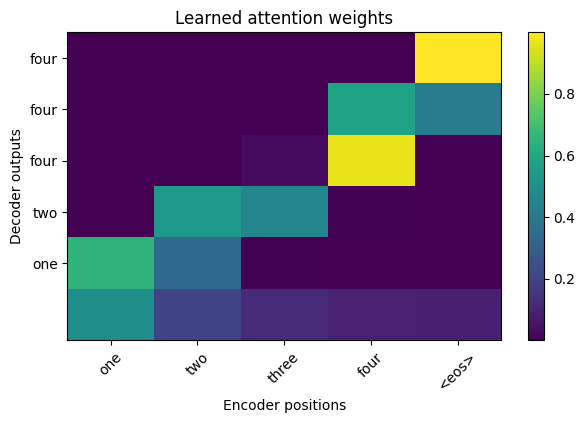

input : ['one', 'two', 'three', 'four']
pred  : ['four', 'four', 'four', 'two', 'one']
truth : ['four', 'three', 'two', 'one']


In [15]:
test_seq = ["one", "two", "three", "four"]
pred_tokens, attn = greedy_decode_attn(attn_model, test_seq)

plt.figure(figsize=(7,4))
plt.imshow(attn.numpy(), aspect="auto")
plt.xticks(range(len(test_seq) + 1), test_seq + ["<eos>"], rotation=45)
plt.yticks(range(len(pred_tokens)), pred_tokens)
plt.xlabel("Encoder positions")
plt.ylabel("Decoder outputs")
plt.title("Learned attention weights")
plt.colorbar()
plt.show()

print("input :", test_seq)
print("pred  :", pred_tokens)
print("truth :", list(reversed(test_seq)))

## Where are the attention parameters learned?
In the `AdditiveAttention` module above, the learnable parameters are:

- `self.W_h`
- `self.W_s`
- `self.v`

They are ordinary PyTorch layers, so they are trained automatically during:
1. forward pass
2. loss computation
3. backpropagation with `.backward()`
4. optimizer update with `.step()`

We can inspect them directly:

In [16]:
for name, param in attn_model.decoder.attention.named_parameters():
    print(name, tuple(param.shape), "requires_grad=", param.requires_grad)

W_h.weight (128, 128) requires_grad= True
W_s.weight (128, 128) requires_grad= True
v.weight (1, 128) requires_grad= True


# Part C — How CNN, RNN, and LSTM fit into encoder–decoder systems

## 1. RNN / LSTM encoder + RNN / LSTM decoder
**Use case:** machine translation, text summarization, conversational modeling, speech-to-text

- Encoder processes source sequence
- Decoder generates target sequence
- Attention often improves performance

## 2. CNN encoder + LSTM decoder
**Use case:** image captioning

- CNN converts image into visual features
- Decoder LSTM generates words
- Attention can focus on image regions

## 3. CNN encoder + CNN decoder
**Use case:** segmentation, image reconstruction

- Encoder compresses spatial information
- Decoder upsamples into output image or mask

## 4. LSTM encoder + classifier decoder
**Use case:** sequence classification

This is not always a full autoregressive decoder, but the encoder–decoder perspective still helps explain the flow of information.

## 5. Encoder–decoder for question answering
There are multiple variants:
- passage encoder + question encoder + answer decoder
- encoder-only extractive QA
- encoder–decoder generative QA
- multimodal QA using image encoder + text decoder

# Part D — Example application sketches

## Image captioning
A common classical pipeline is:

**Image → CNN encoder → visual embedding(s) → LSTM decoder → caption**

Typical datasets:
- Flickr8k
- Flickr30k
- MS COCO

The CNN provides image features, and the LSTM generates a sentence such as:
> "a dog running through grass"

Below is a simple skeleton architecture.

In [17]:
class ImageCaptioningSkeleton(nn.Module):
    def __init__(self, image_feat_dim=512, vocab_size=5000, emb_dim=256, hid_dim=512):
        super().__init__()
        self.image_proj = nn.Linear(image_feat_dim, hid_dim)
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.decoder = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, image_features, captions_in):
        # image_features: [B, image_feat_dim]
        # captions_in: [B, T]
        image_context = self.image_proj(image_features).unsqueeze(1)   # [B,1,H]
        word_emb = self.embedding(captions_in)                         # [B,T,E]
        repeated_context = image_context.repeat(1, word_emb.size(1), 1)
        dec_in = torch.cat([word_emb, repeated_context], dim=-1)
        out, _ = self.decoder(dec_in)
        logits = self.fc_out(out)
        return logits

dummy_image_feats = torch.randn(4, 512)
dummy_captions = torch.randint(0, 5000, (4, 6))
model = ImageCaptioningSkeleton()
logits = model(dummy_image_feats, dummy_captions)
print("captioning logits shape:", tuple(logits.shape))

captioning logits shape: (4, 6, 5000)


## Question answering
An encoder–decoder QA system can be framed as:

**[passage, question] → encoder → decoder → answer**

Examples:
- "Who wrote Hamlet?" → "Shakespeare"
- "What is the capital of France?" → "Paris"

A generative QA system can produce the answer token-by-token.
This is especially useful when:
- the answer is not a simple span copy
- the output must be natural language
- the task is abstractive

Below is a very small sketch of a text QA encoder–decoder.

In [18]:
class QASkeleton(nn.Module):
    def __init__(self, vocab_size=8000, emb_dim=128, hid_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.encoder = nn.LSTM(emb_dim, hid_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(emb_dim + 2*hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, source_tokens, answer_prefix):
        src_emb = self.embedding(source_tokens)
        enc_outputs, _ = self.encoder(src_emb)
        context = enc_outputs.mean(dim=1, keepdim=True)   # simple pooled context
        ans_emb = self.embedding(answer_prefix)
        context_rep = context.repeat(1, ans_emb.size(1), 1)
        dec_in = torch.cat([ans_emb, context_rep], dim=-1)
        dec_out, _ = self.decoder(dec_in)
        logits = self.fc_out(dec_out)
        return logits

dummy_source = torch.randint(0, 8000, (3, 12))
dummy_prefix = torch.randint(0, 8000, (3, 5))
qa_model = QASkeleton()
qa_logits = qa_model(dummy_source, dummy_prefix)
print("QA logits shape:", tuple(qa_logits.shape))

QA logits shape: (3, 5, 8000)


# Part E — Assignments

## Assignment 1: Image Description Generation
Build an image captioning system using a **CNN encoder + LSTM decoder**.

### Task
Given an input image, generate a natural-language caption.

### Suggested dataset
- **Flickr8k** or **Flickr30k**

### Requirements
1. Use a pretrained CNN backbone (for example ResNet18 or ResNet50) as the encoder
2. Add a decoder based on LSTM or GRU
3. Train the model to generate captions
4. Evaluate using at least one caption metric (BLEU is a simple starting point)
5. Show 5 correct predictions and 5 failure cases
6. Explain what kinds of images the model struggles with


In [21]:
# Auto-download Flickr8k (images + captions) if not already present
# This prepares the exact folder layout expected by the Assignment 1 cell.

from pathlib import Path
import urllib.request
import zipfile
import shutil

flickr_root = Path("./Datasets/Flickr8k")
flickr_root.mkdir(parents=True, exist_ok=True)

images_dir = flickr_root / "Images"
caption_file = flickr_root / "Flickr8k.token.txt"


def _download(url: str, out_path: Path):
    print(f"Downloading: {url}")
    urllib.request.urlretrieve(url, out_path)
    print(f"Saved: {out_path}")


def _extract(zip_path: Path, target_dir: Path):
    print(f"Extracting: {zip_path.name}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir)


def _find_best_image_dir(root: Path):
    # Prefer common folder names first
    preferred = []
    for name in ["Images", "Flickr8k_Dataset", "flickr8k_images", "images"]:
        preferred.extend([p for p in root.rglob(name) if p.is_dir()])
    if preferred:
        return preferred[0]

    # Fallback: pick a directory that contains many jpg files
    best_dir, best_count = None, 0
    for d in [p for p in root.rglob("*") if p.is_dir()]:
        count = 0
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            count += len(list(d.glob(ext)))
        if count > best_count:
            best_count = count
            best_dir = d
    return best_dir if best_count > 0 else None


if images_dir.exists() and caption_file.exists():
    print("Flickr8k already prepared in ./Datasets/Flickr8k")
else:
    dataset_zip = flickr_root / "Flickr8k_Dataset.zip"
    text_zip = flickr_root / "Flickr8k_text.zip"

    dataset_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
    text_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

    if not dataset_zip.exists():
        _download(dataset_url, dataset_zip)
    if not text_zip.exists():
        _download(text_url, text_zip)

    # Extract archives
    _extract(dataset_zip, flickr_root)
    _extract(text_zip, flickr_root)

    # Locate extracted resources recursively (handles nested layouts)
    found_image_dir = _find_best_image_dir(flickr_root)
    found_caption_files = list(flickr_root.rglob("Flickr8k.token.txt"))

    if not images_dir.exists() and found_image_dir is not None:
        if found_image_dir.resolve() != images_dir.resolve():
            if images_dir.exists():
                shutil.rmtree(images_dir)
            shutil.move(str(found_image_dir), str(images_dir))

    if not caption_file.exists() and found_caption_files:
        shutil.copy2(found_caption_files[0], caption_file)

    # Copy split files if found (train/test/dev)
    for split_name in ["Flickr_8k.trainImages.txt", "Flickr_8k.testImages.txt", "Flickr_8k.devImages.txt"]:
        dst = flickr_root / split_name
        if not dst.exists():
            found = list(flickr_root.rglob(split_name))
            if found:
                shutil.copy2(found[0], dst)

    if images_dir.exists() and caption_file.exists():
        print("Flickr8k download and setup complete.")
        print("Prepared root:", flickr_root)
        print("Images dir:", images_dir)
        print("Caption file:", caption_file)
    else:
        print("Could not finalize expected layout. Current extracted files:")
        for p in sorted(flickr_root.rglob("*"))[:80]:
            print(" -", p)
        raise RuntimeError(
            "Flickr8k download finished but expected files are still missing. "
            "Check network/download integrity and rerun this cell."
        )

Extracting: Flickr8k_Dataset.zip
Extracting: Flickr8k_text.zip
Flickr8k download and setup complete.
Prepared root: Datasets/Flickr8k
Images dir: Datasets/Flickr8k/Images
Caption file: Datasets/Flickr8k/Flickr8k.token.txt


Using device: cuda
Dataset root: Datasets/Flickr8k
Images dir: Datasets/Flickr8k/Images
Caption file: Datasets/Flickr8k/Flickr8k.token.txt
Train images: 5000, Test images: 1000, Vocab size: 2310
Epoch 1/3 | train loss: 4.4308
Epoch 2/3 | train loss: 3.5328
Epoch 3/3 | train loss: 3.2268

Test BLEU-1 (mean): 0.4915

Correct Predictions


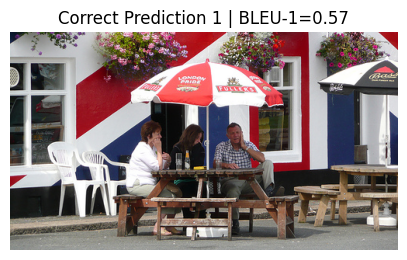

Predicted: a man in a red shirt and a woman are sitting on a bench
Reference example: a couple of people sit outdoors at a table with an umbrella and talk
--------------------------------------------------------------------------------


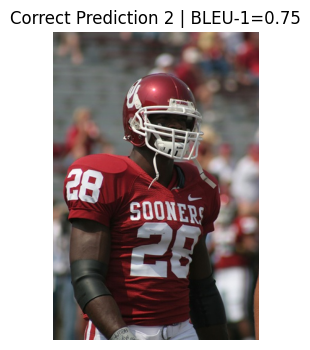

Predicted: a football player in a red shirt is running on the grass
Reference example: a man is wearing a sooners red football shirt and helmet
--------------------------------------------------------------------------------


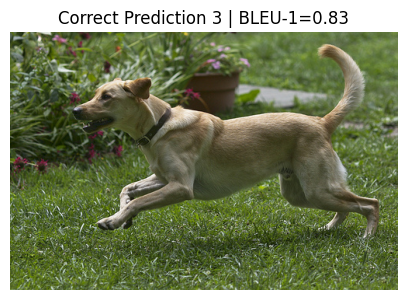

Predicted: a dog runs through the grass
Reference example: a brown dog running
--------------------------------------------------------------------------------


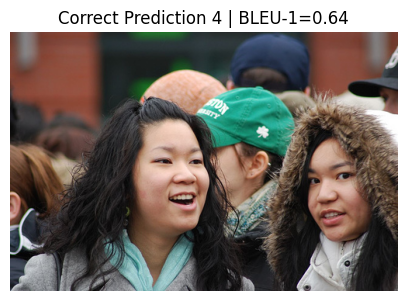

Predicted: a woman with a red shirt is standing in front of a <unk>
Reference example: a girl with dark brown hair and eyes in a blue scarf is standing next to a girl in a fur <unk> coat
--------------------------------------------------------------------------------


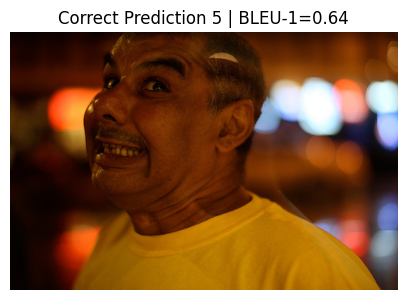

Predicted: a man in a black shirt and a black hat is holding a <unk>
Reference example: a man in yellow <unk>
--------------------------------------------------------------------------------

Failure Cases


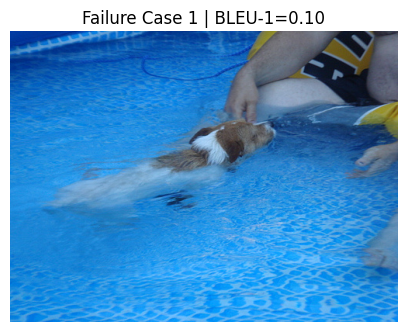

Predicted: two dogs playing with a ball
Reference example: a brown and white dog swimming towards some in the pool
--------------------------------------------------------------------------------


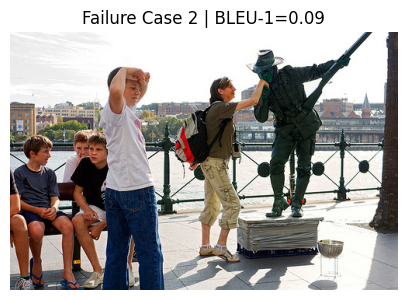

Predicted: two children are playing in the water
Reference example: a group of <unk> stand around as a lady puts her hand near the mouth of a statue
--------------------------------------------------------------------------------


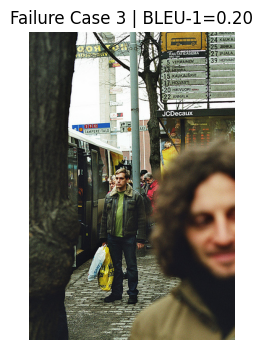

Predicted: a man in a black shirt and a black hat and a black hat and a black hat and a black hat and a black hat and a black dog
Reference example: a man is standing on a sidewalk in the background with a blurry image of another man in the foreground
--------------------------------------------------------------------------------


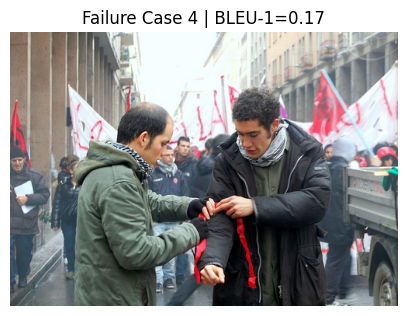

Predicted: a man in a black jacket and a black hat and a black hat and a black hat and a black hat and a black hat and a woman in
Reference example: a man helps another man tie a red ribbon onto his arm
--------------------------------------------------------------------------------


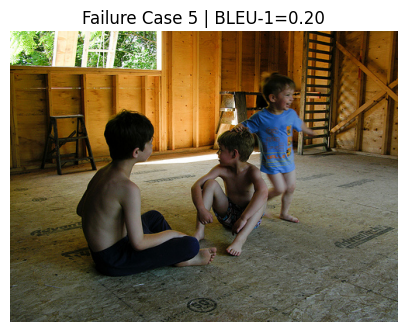

Predicted: a man in a blue shirt and a black shirt and a brown dog is playing with a blue ball
Reference example: three boys in a building under construction
--------------------------------------------------------------------------------

What kinds of images the model struggles with:
- Rare or specific objects not captured by model (seen in 3/5 failure examples)
- Long, detailed captions (many attributes/actions) (seen in 3/5 failure examples)
- Spatial relationships are hard (seen in 2/5 failure examples)


In [28]:
# Assignment 1: Image Captioning (CNN Encoder + LSTM Decoder)
# Requirements covered:
# 1) Pretrained CNN encoder (ResNet50)
# 2) LSTM decoder
# 3) Training loop
# 4) BLEU metric (BLEU-1)
# 5) 5 correct + 5 failure examples
# 6) Error analysis of difficult image types

import os
import re
import random
import math
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility + device
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------
# Config
# ---------------------------
DATASET_ROOT_CANDIDATES = [
    Path("./Datasets/Flickr8k"),
    Path("./Datasets/flickr8k"),
    Path("./Flickr8k"),
    Path("./flickr8k"),
    Path("./Datasets/Flickr30k"),
    Path("./Flickr30k"),
]

BATCH_SIZE = 32
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 1
LR = 1e-3
EPOCHS = 3  # increase to 8-15 for stronger captions
MAX_TRAIN_SAMPLES = 5000  # keep training practical in notebook
MAX_TEST_SAMPLES = 1000
MIN_WORD_FREQ = 5
MAX_CAPTION_LEN = 30

IMG_SIZE = 224

# ---------------------------
# Text helpers
# ---------------------------
TOKEN_PATTERN = re.compile(r"[a-zA-Z0-9']+")

def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())

class Vocab:
    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.specials = ["<pad>", "<sos>", "<eos>", "<unk>"]
        self.stoi = {tok: i for i, tok in enumerate(self.specials)}
        self.itos = list(self.specials)

    @property
    def pad_idx(self):
        return self.stoi["<pad>"]

    @property
    def sos_idx(self):
        return self.stoi["<sos>"]

    @property
    def eos_idx(self):
        return self.stoi["<eos>"]

    @property
    def unk_idx(self):
        return self.stoi["<unk>"]

    def build(self, captions):
        counter = Counter()
        for c in captions:
            counter.update(tokenize(c))
        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def encode(self, text, max_len=None):
        tokens = tokenize(text)
        if max_len is not None:
            tokens = tokens[:max_len]
        ids = [self.sos_idx] + [self.stoi.get(t, self.unk_idx) for t in tokens] + [self.eos_idx]
        return ids

    def decode(self, ids):
        words = []
        for i in ids:
            tok = self.itos[i] if i < len(self.itos) else "<unk>"
            if tok == "<eos>":
                break
            if tok not in {"<pad>", "<sos>"}:
                words.append(tok)
        return " ".join(words)

# ---------------------------
# Flickr parsing
# ---------------------------
def find_flickr_paths(root: Path):
    if not root.exists():
        return None

    # image directory candidates
    image_dir_candidates = [
        root / "Images",
        root / "images",
        root / "flickr8k_images",
        root / "flickr30k_images",
    ]
    image_dir = next((p for p in image_dir_candidates if p.exists()), None)

    # caption file candidates
    caption_file_candidates = [
        root / "captions.txt",
        root / "Flickr8k.token.txt",
        root / "results.csv",
        root / "results_20130124.token",
    ]
    caption_file = next((p for p in caption_file_candidates if p.exists()), None)

    if image_dir is None or caption_file is None:
        return None

    train_split = root / "Flickr_8k.trainImages.txt"
    test_split = root / "Flickr_8k.testImages.txt"
    if not train_split.exists():
        train_split = None
    if not test_split.exists():
        test_split = None

    return {
        "root": root,
        "image_dir": image_dir,
        "caption_file": caption_file,
        "train_split": train_split,
        "test_split": test_split,
    }


def parse_flickr_captions(caption_file: Path):
    image_to_captions = defaultdict(list)

    # Format A: Flickr8k.token.txt => image.jpg#0\tcaption
    # Format B: captions.txt => image,caption
    with open(caption_file, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.read().splitlines()

    # Auto-detect CSV-like header
    csv_like = len(lines) > 0 and ("image" in lines[0].lower() and "caption" in lines[0].lower() and "," in lines[0])

    if csv_like:
        for line in lines[1:]:
            if not line.strip():
                continue
            if "," not in line:
                continue
            img, cap = line.split(",", 1)
            img = img.strip()
            cap = cap.strip().strip('"')
            if img:
                image_to_captions[img].append(cap)
    else:
        for line in lines:
            if not line.strip():
                continue
            if "\t" in line:
                left, cap = line.split("\t", 1)
            elif "," in line:
                left, cap = line.split(",", 1)
            else:
                continue

            left = left.strip()
            cap = cap.strip().strip('"')
            img = left.split("#")[0]  # handles image.jpg#0
            if img:
                image_to_captions[img].append(cap)

    # keep only images with at least one caption
    image_to_captions = {k: v for k, v in image_to_captions.items() if len(v) > 0}
    return image_to_captions


def load_flickr_dataset_info(candidates):
    for root in candidates:
        paths = find_flickr_paths(root)
        if paths is not None:
            return paths
    return None

# ---------------------------
# Dataset + collate
# ---------------------------
class FlickrCaptionDataset(Dataset):
    def __init__(self, image_dir, image_to_captions, image_names, vocab, transform=None, train=True):
        self.image_dir = Path(image_dir)
        self.image_to_captions = image_to_captions
        self.image_names = image_names
        self.vocab = vocab
        self.transform = transform
        self.train = train

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        img_path = self.image_dir / image_name
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        captions = self.image_to_captions[image_name]
        if self.train:
            cap = random.choice(captions)
            cap_ids = torch.tensor(self.vocab.encode(cap, max_len=MAX_CAPTION_LEN), dtype=torch.long)
            return image, cap_ids
        else:
            # return all references for BLEU and qualitative analysis
            refs = [self.vocab.encode(c, max_len=MAX_CAPTION_LEN) for c in captions]
            return image, refs, image_name


def collate_train(batch, pad_idx):
    images, caps = zip(*batch)
    images = torch.stack(images, dim=0)

    lengths = [len(c) for c in caps]
    max_len = max(lengths)
    padded = torch.full((len(caps), max_len), pad_idx, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :len(c)] = c
    return images, padded

# ---------------------------
# Model
# ---------------------------
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(backbone.children())[:-1]  # remove fc
        self.cnn = nn.Sequential(*modules)
        self.proj = nn.Linear(backbone.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size)

    def forward(self, images):
        with torch.no_grad():
            feats = self.cnn(images)  # B, 512, 1, 1
        feats = feats.flatten(1)
        feats = self.proj(feats)
        feats = self.bn(feats)
        return feats


class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, pad_idx):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.h0_proj = nn.Linear(embed_size, hidden_size)
        self.c0_proj = nn.Linear(embed_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, img_feats, captions_in):
        # captions_in shape: B, T  (teacher forcing inputs)
        emb = self.embed(captions_in)  # B, T, E

        h0 = torch.tanh(self.h0_proj(img_feats)).unsqueeze(0)  # 1, B, H
        c0 = torch.tanh(self.c0_proj(img_feats)).unsqueeze(0)

        out, _ = self.lstm(emb, (h0, c0))
        logits = self.fc(out)  # B, T, V
        return logits

    def generate(self, img_feats, sos_idx, eos_idx, max_len=25):
        # Greedy decoding for one image feature vector
        h = torch.tanh(self.h0_proj(img_feats)).unsqueeze(0)
        c = torch.tanh(self.c0_proj(img_feats)).unsqueeze(0)

        cur = torch.tensor([[sos_idx]], device=img_feats.device)
        generated = []
        for _ in range(max_len):
            emb = self.embed(cur)
            out, (h, c) = self.lstm(emb, (h, c))
            logits = self.fc(out[:, -1, :])
            nxt = logits.argmax(dim=-1)
            token_id = nxt.item()
            if token_id == eos_idx:
                break
            generated.append(token_id)
            cur = nxt.unsqueeze(1)
        return generated


class CaptionModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, pad_idx):
        super().__init__()
        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderLSTM(vocab_size, embed_size, hidden_size, num_layers, pad_idx)

    def forward(self, images, captions_in):
        feats = self.encoder(images)
        return self.decoder(feats, captions_in)

# ---------------------------
# BLEU-1 metric
# ---------------------------
def bleu1_score(reference_tokens_list, candidate_tokens):
    # reference_tokens_list: list of token lists
    # candidate_tokens: token list
    if len(candidate_tokens) == 0:
        return 0.0

    cand_counts = Counter(candidate_tokens)
    max_ref_counts = Counter()
    for ref in reference_tokens_list:
        ref_counts = Counter(ref)
        for tok in ref_counts:
            max_ref_counts[tok] = max(max_ref_counts[tok], ref_counts[tok])

    clipped = 0
    total = sum(cand_counts.values())
    for tok, c in cand_counts.items():
        clipped += min(c, max_ref_counts.get(tok, 0))

    precision = clipped / max(total, 1)

    # brevity penalty
    c = len(candidate_tokens)
    ref_lens = [len(r) for r in reference_tokens_list]
    r = min(ref_lens, key=lambda rl: abs(rl - c)) if ref_lens else c
    if c > r:
        bp = 1.0
    else:
        bp = math.exp(1 - (r / max(c, 1)))

    return bp * precision

# ---------------------------
# Data loading setup
# ---------------------------
paths = load_flickr_dataset_info(DATASET_ROOT_CANDIDATES)
if paths is None:
    raise FileNotFoundError(
        "Could not find Flickr8k/Flickr30k in expected locations. "
        "Set DATASET_ROOT_CANDIDATES to your dataset folder containing image files and captions file."
    )

print("Dataset root:", paths["root"])
print("Images dir:", paths["image_dir"])
print("Caption file:", paths["caption_file"])

image_to_captions = parse_flickr_captions(paths["caption_file"])
all_images = sorted(list(image_to_captions.keys()))

# Keep only images that physically exist
all_images = [im for im in all_images if (paths["image_dir"] / im).exists()]

if len(all_images) == 0:
    raise RuntimeError("No matching images found in image folder for parsed captions.")

if paths["train_split"] and paths["test_split"]:
    train_images = [x.strip() for x in open(paths["train_split"], "r", encoding="utf-8").read().splitlines() if x.strip()]
    test_images = [x.strip() for x in open(paths["test_split"], "r", encoding="utf-8").read().splitlines() if x.strip()]

    train_images = [im for im in train_images if im in image_to_captions and (paths["image_dir"] / im).exists()]
    test_images = [im for im in test_images if im in image_to_captions and (paths["image_dir"] / im).exists()]
else:
    random.shuffle(all_images)
    split = int(0.8 * len(all_images))
    train_images = all_images[:split]
    test_images = all_images[split:]

# Optional downsampling for notebook runtime
train_images = train_images[:MAX_TRAIN_SAMPLES]
test_images = test_images[:MAX_TEST_SAMPLES]

train_caps_flat = []
for im in train_images:
    train_caps_flat.extend(image_to_captions[im])

vocab = Vocab(min_freq=MIN_WORD_FREQ)
vocab.build(train_caps_flat)
print(f"Train images: {len(train_images)}, Test images: {len(test_images)}, Vocab size: {len(vocab.itos)}")

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_ds = FlickrCaptionDataset(paths["image_dir"], image_to_captions, train_images, vocab, transform=train_tfms, train=True)
test_ds = FlickrCaptionDataset(paths["image_dir"], image_to_captions, test_images, vocab, transform=test_tfms, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda b: collate_train(b, vocab.pad_idx),
)

# ---------------------------
# Train
# ---------------------------
model = CaptionModel(
    vocab_size=len(vocab.itos),
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    pad_idx=vocab.pad_idx,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
params = list(model.decoder.parameters()) + list(model.encoder.proj.parameters()) + list(model.encoder.bn.parameters())
optimizer = optim.Adam(params, lr=LR)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for images, caps in train_loader:
        images = images.to(device)
        caps = caps.to(device)

        # teacher forcing: input <sos>...w_{t-1}; target w_1...<eos>
        captions_in = caps[:, :-1]
        targets = caps[:, 1:]

        logits = model(images, captions_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        running += loss.item()

    avg_loss = running / max(len(train_loader), 1)
    print(f"Epoch {epoch}/{EPOCHS} | train loss: {avg_loss:.4f}")

# ---------------------------
# Evaluate BLEU-1 + collect examples
# ---------------------------
model.eval()

correct_cases = []
failure_cases = []
all_bleu = []

with torch.no_grad():
    for i in range(len(test_ds)):
        image_tensor, refs_ids, image_name = test_ds[i]
        image_batch = image_tensor.unsqueeze(0).to(device)

        img_feats = model.encoder(image_batch)
        pred_ids = model.decoder.generate(img_feats, vocab.sos_idx, vocab.eos_idx, max_len=MAX_CAPTION_LEN)

        pred_text = vocab.decode(pred_ids)
        pred_tokens = tokenize(pred_text)

        refs_text = [vocab.decode(r) for r in refs_ids]
        refs_tokens = [tokenize(t) for t in refs_text]

        bleu1 = bleu1_score(refs_tokens, pred_tokens)
        all_bleu.append(bleu1)

        record = {
            "image_name": image_name,
            "pred": pred_text,
            "refs": refs_text,
            "bleu1": bleu1,
        }

        # Practical thresholds for qualitative grouping
        if bleu1 >= 0.55 and len(correct_cases) < 5:
            correct_cases.append(record)
        elif bleu1 <= 0.20 and len(failure_cases) < 5:
            failure_cases.append(record)

        if len(correct_cases) >= 5 and len(failure_cases) >= 5:
            break

mean_bleu1 = float(np.mean(all_bleu)) if all_bleu else 0.0
print(f"\nTest BLEU-1 (mean): {mean_bleu1:.4f}")

# If strict thresholds did not fill slots, backfill by sorting
if len(correct_cases) < 5 or len(failure_cases) < 5:
    # Recompute full records once for robust fallback
    full_records = []
    with torch.no_grad():
        for i in range(len(test_ds)):
            image_tensor, refs_ids, image_name = test_ds[i]
            image_batch = image_tensor.unsqueeze(0).to(device)
            img_feats = model.encoder(image_batch)
            pred_ids = model.decoder.generate(img_feats, vocab.sos_idx, vocab.eos_idx, max_len=MAX_CAPTION_LEN)
            pred_text = vocab.decode(pred_ids)
            pred_tokens = tokenize(pred_text)
            refs_text = [vocab.decode(r) for r in refs_ids]
            refs_tokens = [tokenize(t) for t in refs_text]
            bleu1 = bleu1_score(refs_tokens, pred_tokens)
            full_records.append({"image_name": image_name, "pred": pred_text, "refs": refs_text, "bleu1": bleu1})

    full_records_sorted = sorted(full_records, key=lambda x: x["bleu1"], reverse=True)
    correct_cases = full_records_sorted[:5]
    failure_cases = full_records_sorted[-5:]

# ---------------------------
# Display 5 correct + 5 failures
# ---------------------------
def show_cases(case_list, title):
    print(f"\n{title}")
    for idx, c in enumerate(case_list, 1):
        img_path = paths["image_dir"] / c["image_name"]
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{title[:-1]} {idx} | BLEU-1={c['bleu1']:.2f}")
        plt.show()

        print("Predicted:", c["pred"])
        print("Reference example:", c["refs"][0] if c["refs"] else "N/A")
        print("-" * 80)

show_cases(correct_cases, "Correct Predictions")
show_cases(failure_cases, "Failure Cases")

# ---------------------------
# Failure analysis (requirement 6)
# ---------------------------
def analyze_failures(failure_records):
    reasons = Counter()
    for r in failure_records:
        pred_toks = tokenize(r["pred"])
        ref_toks = tokenize(r["refs"][0] if r["refs"] else "")

        if len(ref_toks) >= 12:
            reasons["Long, detailed captions (many attributes/actions)"] += 1
        if len(set(ref_toks)) - len(set(pred_toks)) >= 4:
            reasons["Rare or specific objects not captured by model"] += 1
        if ref_toks.count("and") + ref_toks.count("with") >= 2:
            reasons["Multiple objects/relations in one image"] += 1
        if any(w in ref_toks for w in ["behind", "front", "next", "near", "under", "over"]):
            reasons["Spatial relationships are hard"] += 1
        if len(pred_toks) <= 3:
            reasons["Model outputs short/generic captions"] += 1

    if not reasons:
        print("No strong failure pattern detected from current sample.")
        return

    print("\nWhat kinds of images the model struggles with:")
    for k, v in reasons.most_common():
        print(f"- {k} (seen in {v}/{len(failure_records)} failure examples)")

analyze_failures(failure_cases)


## Assignment 2: Question Answering with Encoder–Decoder
Build a generative QA model.

### Task
Given a context passage and a question, generate the answer.

### Suggested datasets
- **SQuAD** (for text QA)
- a small curated QA dataset made in class
- a synthetic QA dataset for low-compute experiments

### Requirements
1. Concatenate or otherwise combine passage and question
2. Use an encoder to build hidden representations
3. Use a decoder to generate the answer token-by-token
4. Compare performance with and without attention
5. Analyze at least 5 errors


In [27]:
# Assignment 2: Generative QA with Encoder-Decoder
# Requirements covered:
# 1) Passage + question are combined using <sep>
# 2) Encoder builds hidden representations
# 3) Decoder generates answer token-by-token
# 4) Compare with vs without attention
# 5) Analyze at least 5 errors

import random
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ---------------------------
# Reproducibility + device
# ---------------------------
QA2_SEED = 123
random.seed(QA2_SEED)
torch.manual_seed(QA2_SEED)
torch.cuda.manual_seed_all(QA2_SEED)
qa2_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("QA2 device:", qa2_device)

# ---------------------------
# Synthetic QA data
# ---------------------------
NAMES = [
    "alice", "bob", "carol", "dave", "erin", "frank", "gina", "henry", "ivy", "jack",
    "karen", "leo", "maya", "nina", "omar", "paul", "quinn", "rachel", "sam", "tina",
    "uma", "victor", "wendy", "xavier", "yasmin", "zack"
]
FOODS = ["pizza", "sushi", "tacos", "pasta", "salad", "ramen", "burger", "curry", "steak", "noodles"]
CITIES = ["paris", "rome", "tokyo", "london", "madrid", "berlin", "dublin", "oslo", "lisbon", "athens"]
PETS = ["dog", "cat", "parrot", "rabbit", "hamster", "turtle", "fish", "horse"]
NOISE = ["today", "cloudy", "school", "market", "music", "green", "quick", "bright"]

RELATIONS = ["likes", "lives_in", "owns"]


def make_qa2_example():
    n_people = random.randint(6, 11)
    people = random.sample(NAMES, n_people)

    likes = {p: random.choice(FOODS) for p in people}
    lives = {p: random.choice(CITIES) for p in people}
    owns = {p: random.choice(PETS) for p in people}

    facts = []
    for p in people:
        facts.append([p, "likes", likes[p], "."])
        facts.append([p, "lives_in", lives[p], "."])
        facts.append([p, "owns", owns[p], "."])

    # add noise facts to make retrieval harder
    for _ in range(random.randint(3, 7)):
        facts.append([random.choice(NOISE), "is", random.choice(NOISE), "."])

    random.shuffle(facts)

    target_person = random.choice(people)
    target_rel = random.choice(RELATIONS)

    if target_rel == "likes":
        q_tokens = ["what", "does", target_person, "like", "?"]
        a_tokens = [likes[target_person]]
    elif target_rel == "lives_in":
        q_tokens = ["where", "does", target_person, "live", "?"]
        a_tokens = [lives[target_person]]
    else:
        q_tokens = ["what", "pet", "does", target_person, "own", "?"]
        a_tokens = [owns[target_person]]

    context_tokens = []
    for f in facts:
        context_tokens.extend(f)

    src_tokens = context_tokens + ["<sep>"] + q_tokens
    return src_tokens, a_tokens, target_rel


def build_qa2_split(n):
    data = [make_qa2_example() for _ in range(n)]
    return data

qa2_train_raw = build_qa2_split(4500)
qa2_val_raw = build_qa2_split(900)
qa2_test_raw = build_qa2_split(900)

print("QA2 dataset sizes:", len(qa2_train_raw), len(qa2_val_raw), len(qa2_test_raw))

# ---------------------------
# Vocab + dataset
# ---------------------------
QA2_SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]

class QA2Vocab:
    def __init__(self):
        self.stoi = {t: i for i, t in enumerate(QA2_SPECIALS)}
        self.itos = list(QA2_SPECIALS)

    @property
    def pad_idx(self):
        return self.stoi["<pad>"]

    @property
    def sos_idx(self):
        return self.stoi["<sos>"]

    @property
    def eos_idx(self):
        return self.stoi["<eos>"]

    @property
    def unk_idx(self):
        return self.stoi["<unk>"]

    def build(self, examples):
        c = Counter()
        for src, ans, _ in examples:
            c.update(src)
            c.update(ans)
        for tok, _freq in c.items():
            if tok not in self.stoi:
                self.stoi[tok] = len(self.itos)
                self.itos.append(tok)

    def encode(self, tokens):
        return [self.stoi.get(t, self.unk_idx) for t in tokens]

    def decode(self, ids):
        out = []
        for idx in ids:
            tok = self.itos[int(idx)] if int(idx) < len(self.itos) else "<unk>"
            if tok == "<eos>":
                break
            if tok not in {"<sos>", "<pad>"}:
                out.append(tok)
        return out

qa2_vocab = QA2Vocab()
qa2_vocab.build(qa2_train_raw)

class QA2Dataset(Dataset):
    def __init__(self, raw_data, vocab):
        self.items = []
        self.vocab = vocab
        for src_tokens, ans_tokens, rel in raw_data:
            src_ids = vocab.encode(src_tokens) + [vocab.eos_idx]
            tgt_ids = [vocab.sos_idx] + vocab.encode(ans_tokens) + [vocab.eos_idx]
            self.items.append((src_ids, tgt_ids, src_tokens, ans_tokens, rel))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]


def qa2_collate(batch):
    src_ids, tgt_ids, src_toks, ans_toks, rels = zip(*batch)

    bsz = len(batch)
    max_src = max(len(x) for x in src_ids)
    max_tgt = max(len(x) for x in tgt_ids)

    src_tensor = torch.full((bsz, max_src), qa2_vocab.pad_idx, dtype=torch.long)
    tgt_tensor = torch.full((bsz, max_tgt), qa2_vocab.pad_idx, dtype=torch.long)

    for i, (s, t) in enumerate(zip(src_ids, tgt_ids)):
        src_tensor[i, :len(s)] = torch.tensor(s, dtype=torch.long)
        tgt_tensor[i, :len(t)] = torch.tensor(t, dtype=torch.long)

    return src_tensor, tgt_tensor, src_toks, ans_toks, rels

qa2_train_ds = QA2Dataset(qa2_train_raw, qa2_vocab)
qa2_val_ds = QA2Dataset(qa2_val_raw, qa2_vocab)
qa2_test_ds = QA2Dataset(qa2_test_raw, qa2_vocab)

qa2_train_loader = DataLoader(qa2_train_ds, batch_size=64, shuffle=True, collate_fn=qa2_collate)
qa2_val_loader = DataLoader(qa2_val_ds, batch_size=64, shuffle=False, collate_fn=qa2_collate)
qa2_test_loader = DataLoader(qa2_test_ds, batch_size=64, shuffle=False, collate_fn=qa2_collate)

print("QA2 vocab size:", len(qa2_vocab.itos))

# ---------------------------
# Models (without attention)
# ---------------------------
class QA2Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hid_dim=192):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=qa2_vocab.pad_idx)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(emb)
        return outputs, hidden, cell

class QA2DecoderNoAttn(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hid_dim=192):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=qa2_vocab.pad_idx)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tok, hidden, cell):
        emb = self.embedding(input_tok).unsqueeze(1)
        out, (hidden, cell) = self.lstm(emb, (hidden, cell))
        logits = self.fc(out.squeeze(1))
        return logits, hidden, cell

class QA2Seq2SeqNoAttn(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab_size = vocab_size

    def forward(self, src, tgt, teacher_forcing=0.6):
        bsz, tgt_len = tgt.shape
        outputs = torch.zeros(bsz, tgt_len, self.vocab_size, device=src.device)

        _, hidden, cell = self.encoder(src)
        inp = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, cell = self.decoder(inp, hidden, cell)
            outputs[:, t] = logits
            use_tf = random.random() < teacher_forcing
            top1 = logits.argmax(dim=1)
            inp = tgt[:, t] if use_tf else top1
        return outputs

# ---------------------------
# Models (with attention)
# ---------------------------
class QA2AdditiveAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W_h = nn.Linear(hid_dim, hid_dim, bias=False)
        self.W_s = nn.Linear(hid_dim, hid_dim, bias=False)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, src_mask=None):
        # dec_hidden: [B,H], enc_outputs: [B,S,H]
        dec = dec_hidden.unsqueeze(1).repeat(1, enc_outputs.size(1), 1)
        energy = torch.tanh(self.W_h(enc_outputs) + self.W_s(dec))
        scores = self.v(energy).squeeze(-1)
        if src_mask is not None:
            scores = scores.masked_fill(~src_mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        ctx = torch.bmm(weights.unsqueeze(1), enc_outputs).squeeze(1)
        return ctx, weights

class QA2DecoderAttn(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hid_dim=192):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=qa2_vocab.pad_idx)
        self.attn = QA2AdditiveAttention(hid_dim)
        self.lstm = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim * 2, vocab_size)

    def forward(self, input_tok, hidden, cell, enc_outputs, src_mask=None):
        emb = self.embedding(input_tok)
        dec_hidden = hidden[-1]
        ctx, weights = self.attn(dec_hidden, enc_outputs, src_mask)
        dec_in = torch.cat([emb, ctx], dim=1).unsqueeze(1)
        out, (hidden, cell) = self.lstm(dec_in, (hidden, cell))
        logits = self.fc(torch.cat([out.squeeze(1), ctx], dim=1))
        return logits, hidden, cell, weights

class QA2Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab_size = vocab_size

    def make_src_mask(self, src):
        return src != qa2_vocab.pad_idx

    def forward(self, src, tgt, teacher_forcing=0.6):
        bsz, tgt_len = tgt.shape
        outputs = torch.zeros(bsz, tgt_len, self.vocab_size, device=src.device)

        enc_outputs, hidden, cell = self.encoder(src)
        src_mask = self.make_src_mask(src)
        inp = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, cell, _weights = self.decoder(inp, hidden, cell, enc_outputs, src_mask)
            outputs[:, t] = logits
            use_tf = random.random() < teacher_forcing
            top1 = logits.argmax(dim=1)
            inp = tgt[:, t] if use_tf else top1
        return outputs

# ---------------------------
# Train + evaluate helpers
# ---------------------------
def qa2_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for src, tgt, _src_toks, _ans_toks, _rels in loader:
        src, tgt = src.to(qa2_device), tgt.to(qa2_device)
        optimizer.zero_grad()
        out = model(src, tgt, teacher_forcing=0.6)
        loss = criterion(out[:, 1:].reshape(-1, out.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / max(len(loader), 1)

@torch.no_grad()
def qa2_eval_loss(model, loader, criterion):
    model.eval()
    total = 0.0
    for src, tgt, _src_toks, _ans_toks, _rels in loader:
        src, tgt = src.to(qa2_device), tgt.to(qa2_device)
        out = model(src, tgt, teacher_forcing=0.0)
        loss = criterion(out[:, 1:].reshape(-1, out.size(-1)), tgt[:, 1:].reshape(-1))
        total += loss.item()
    return total / max(len(loader), 1)

@torch.no_grad()
def qa2_decode_no_attn(model, src_tensor, max_len=5):
    model.eval()
    _enc_outputs, hidden, cell = model.encoder(src_tensor)
    inp = torch.tensor([qa2_vocab.sos_idx], device=src_tensor.device)
    out_ids = []
    for _ in range(max_len):
        logits, hidden, cell = model.decoder(inp, hidden, cell)
        nxt = logits.argmax(dim=1)
        idx = int(nxt.item())
        if idx == qa2_vocab.eos_idx:
            break
        out_ids.append(idx)
        inp = nxt
    return out_ids

@torch.no_grad()
def qa2_decode_attn(model, src_tensor, max_len=5):
    model.eval()
    enc_outputs, hidden, cell = model.encoder(src_tensor)
    src_mask = model.make_src_mask(src_tensor)
    inp = torch.tensor([qa2_vocab.sos_idx], device=src_tensor.device)
    out_ids = []
    for _ in range(max_len):
        logits, hidden, cell, _w = model.decoder(inp, hidden, cell, enc_outputs, src_mask)
        nxt = logits.argmax(dim=1)
        idx = int(nxt.item())
        if idx == qa2_vocab.eos_idx:
            break
        out_ids.append(idx)
        inp = nxt
    return out_ids

@torch.no_grad()
def qa2_evaluate_predictions(model, test_ds, use_attention=False):
    exact = 0
    total = 0
    errors = []

    for src_ids, _tgt_ids, src_toks, ans_toks, rel in test_ds.items:
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=qa2_device)

        if use_attention:
            pred_ids = qa2_decode_attn(model, src_tensor)
        else:
            pred_ids = qa2_decode_no_attn(model, src_tensor)

        pred_toks = qa2_vocab.decode(pred_ids)
        total += 1
        ok = pred_toks == ans_toks
        exact += int(ok)

        if not ok:
            sep_pos = src_toks.index("<sep>") if "<sep>" in src_toks else len(src_toks)
            context = " ".join(src_toks[:sep_pos])
            question = " ".join(src_toks[sep_pos + 1:]) if sep_pos < len(src_toks) else ""
            errors.append({
                "context": context,
                "question": question,
                "truth": " ".join(ans_toks),
                "pred": " ".join(pred_toks) if pred_toks else "<empty>",
                "relation": rel,
                "context_len": len(src_toks)
            })

    return {
        "exact_match": exact / max(total, 1),
        "errors": errors,
        "total": total
    }

# ---------------------------
# Train both models
# ---------------------------
qa2_vocab_size = len(qa2_vocab.itos)
qa2_epochs = 3

enc_no = QA2Encoder(qa2_vocab_size).to(qa2_device)
dec_no = QA2DecoderNoAttn(qa2_vocab_size).to(qa2_device)
qa2_no_attn_model = QA2Seq2SeqNoAttn(enc_no, dec_no, qa2_vocab_size).to(qa2_device)

enc_at = QA2Encoder(qa2_vocab_size).to(qa2_device)
dec_at = QA2DecoderAttn(qa2_vocab_size).to(qa2_device)
qa2_attn_model = QA2Seq2SeqAttn(enc_at, dec_at, qa2_vocab_size).to(qa2_device)

qa2_criterion = nn.CrossEntropyLoss(ignore_index=qa2_vocab.pad_idx)
qa2_opt_no = optim.Adam(qa2_no_attn_model.parameters(), lr=0.003)
qa2_opt_at = optim.Adam(qa2_attn_model.parameters(), lr=0.003)

print("\nTraining QA model WITHOUT attention")
for ep in range(1, qa2_epochs + 1):
    tr = qa2_train_epoch(qa2_no_attn_model, qa2_train_loader, qa2_opt_no, qa2_criterion)
    va = qa2_eval_loss(qa2_no_attn_model, qa2_val_loader, qa2_criterion)
    print(f"NoAttn Epoch {ep}/{qa2_epochs} | train={tr:.4f} | val={va:.4f}")

print("\nTraining QA model WITH attention")
for ep in range(1, qa2_epochs + 1):
    tr = qa2_train_epoch(qa2_attn_model, qa2_train_loader, qa2_opt_at, qa2_criterion)
    va = qa2_eval_loss(qa2_attn_model, qa2_val_loader, qa2_criterion)
    print(f"Attn   Epoch {ep}/{qa2_epochs} | train={tr:.4f} | val={va:.4f}")

# ---------------------------
# Compare performance
# ---------------------------
qa2_no_metrics = qa2_evaluate_predictions(qa2_no_attn_model, qa2_test_ds, use_attention=False)
qa2_at_metrics = qa2_evaluate_predictions(qa2_attn_model, qa2_test_ds, use_attention=True)

print("\nPerformance comparison on test set (Exact Match):")
print(f"- Without attention: {qa2_no_metrics['exact_match']:.4f}")
print(f"- With attention   : {qa2_at_metrics['exact_match']:.4f}")

# ---------------------------
# Error analysis (>=5)
# ---------------------------
# Prefer analyzing no-attention errors to highlight differences.
qa2_errors = qa2_no_metrics["errors"]
if len(qa2_errors) < 5:
    # Backfill with attention errors if needed
    qa2_errors = qa2_errors + qa2_at_metrics["errors"]

qa2_errors = qa2_errors[:5]

print("\nFive error cases:")
for i, e in enumerate(qa2_errors, 1):
    print(f"\nError {i}")
    print("Question:", e["question"])
    print("True answer:", e["truth"])
    print("Predicted  :", e["pred"])
    print("Context length:", e["context_len"], "tokens")
    print("Relation:", e["relation"])

len_bucket = Counter()
rel_counter = Counter()
for e in qa2_errors:
    if e["context_len"] < 60:
        len_bucket["short_context"] += 1
    elif e["context_len"] < 90:
        len_bucket["medium_context"] += 1
    else:
        len_bucket["long_context"] += 1
    rel_counter[e["relation"]] += 1

print("\nError analysis summary:")
for k, v in len_bucket.items():
    print(f"- {k}: {v}/5")
for k, v in rel_counter.items():
    print(f"- relation '{k}': {v}/5")


QA2 device: cuda
QA2 dataset sizes: 4500 900 900
QA2 vocab size: 80

Training QA model WITHOUT attention
NoAttn Epoch 1/3 | train=1.8788 | val=1.6841
NoAttn Epoch 2/3 | train=1.5148 | val=1.3901
NoAttn Epoch 3/3 | train=1.2858 | val=1.1620

Training QA model WITH attention
Attn   Epoch 1/3 | train=1.8461 | val=1.6109
Attn   Epoch 2/3 | train=1.1982 | val=1.1599
Attn   Epoch 3/3 | train=1.1377 | val=1.1307

Performance comparison on test set (Exact Match):
- Without attention: 0.1200
- With attention   : 0.1167

Five error cases:

Error 1
Question: what does quinn like ?
True answer: ramen
Predicted  : salad
Context length: 138 tokens
Relation: likes

Error 2
Question: what pet does dave own ?
True answer: turtle
Predicted  : fish
Context length: 103 tokens
Relation: owns

Error 3
Question: what does wendy like ?
True answer: pasta
Predicted  : salad
Context length: 142 tokens
Relation: likes

Error 4
Question: where does sam live ?
True answer: rome
Predicted  : tokyo
Context length: 1